In [41]:
import pandas as pd  # Tabelle
import numpy as np   # Numerico

from ucimlrepo import fetch_ucirepo  # Dataset UCI


# Scarica il dataset completo UCI (ID = 300)
dataset = fetch_ucirepo(id=300)

#  Features e target

# X = tutte le variabili indipendenti
X = dataset.data.features

# y = variabile target (risultato match)
y = dataset.data.targets


#  Unisco per EDA

# Creo unico dataframe per analisi
df = pd.concat([X, y], axis=1)


print("Shape dataset:", df.shape)
print("\nPrime 5 righe:")
print(df.head())
print(df.columns.tolist())

Shape dataset: (943, 43)

Prime 5 righe:
    Tournament           Player1          Player2  Round  FNL1  FNL2  FSP.1  \
0  AusOpen-men       Lukas Lacko   Novak Djokovic      1   0.0   3.0     61   
1  AusOpen-men    Leonardo Mayer  Albert Montanes      1   3.0   0.0     61   
2  AusOpen-men  Marcos Baghdatis    Denis Istomin      1   0.0   3.0     52   
3  AusOpen-men   Dmitry Tursunov  Michael Russell      1   3.0   0.0     53   
4  AusOpen-men       Juan Monaco   Ernests Gulbis      1   1.0   3.0     76   

   FSW.1  SSP.1  SSW.1  ...  BPW.2  NPA.2  NPW.2  TPW.2  ST1.2  ST2.2  ST3.2  \
0     35     39     18  ...    8.0    8.0    9.0  101.0    6.0    7.0    6.0   
1     31     39     13  ...    0.0    NaN    NaN   42.0    1.0    3.0    1.0   
2     53     48     20  ...   13.0   12.0   16.0  126.0    6.0    7.0    6.0   
3     39     47     24  ...    7.0    NaN    NaN   79.0    2.0    2.0    3.0   
4     63     24     12  ...    5.0   16.0   28.0  127.0    1.0    6.0    7.0   

   

In [7]:
print("\nTipi colonne:")
print(df.dtypes)

print("\nConteggio tipi:")
print(df.dtypes.value_counts())



Tipi colonne:
Tournament     object
Player1        object
Player2        object
Round           int64
FNL1          float64
FNL2          float64
FSP.1           int64
FSW.1           int64
SSP.1           int64
SSW.1           int64
ACE.1         float64
DBF.1         float64
WNR.1         float64
UFE.1         float64
BPC.1         float64
BPW.1         float64
NPA.1         float64
NPW.1         float64
TPW.1         float64
ST1.1         float64
ST2.1         float64
ST3.1         float64
ST4.1         float64
ST5.1         float64
FSP.2           int64
FSW.2           int64
SSP.2           int64
SSW.2           int64
ACE.2         float64
DBF.2         float64
WNR.2         float64
UFE.2         float64
BPC.2         float64
BPW.2         float64
NPA.2         float64
NPW.2         float64
TPW.2         float64
ST1.2         float64
ST2.2         float64
ST3.2         float64
ST4.2         float64
ST5.2         float64
Result          int64
dtype: object

Conteggio tipi:
float64 


Missing values

In [15]:
# Quanti NaN totali
print("\nMissing totali:", df.isna().sum().sum())

# Missing per colonna
missing_per_col = df.isna().sum().sort_values(ascending=False)

print("\nTop 20 colonne con più missing:")
print(missing_per_col.head(30))



Missing totali: 5338

Top 20 colonne con più missing:
ST5.1    857
ST5.2    857
ST4.2    722
ST4.1    722
ST3.1    321
ST3.2    321
TPW.2    312
TPW.1    312
UFE.2    126
WNR.1    126
UFE.1    126
WNR.2    126
NPA.1     84
NPA.2     84
NPW.2     83
NPW.1     83
ACE.2     22
ACE.1     22
DBF.2      8
DBF.1      8
ST2.2      4
ST2.1      4
FNL1       1
FNL2       1
BPW.1      1
BPC.1      1
ST1.1      1
ST1.2      1
BPW.2      1
BPC.2      1
dtype: int64


In [17]:
# Percentuale missing
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

print("\n% Missing per colonna:")
print(missing_percent.head(30))



% Missing per colonna:
ST5.1    90.880170
ST5.2    90.880170
ST4.2    76.564157
ST4.1    76.564157
ST3.1    34.040297
ST3.2    34.040297
TPW.2    33.085896
TPW.1    33.085896
UFE.2    13.361612
WNR.1    13.361612
UFE.1    13.361612
WNR.2    13.361612
NPA.1     8.907741
NPA.2     8.907741
NPW.2     8.801697
NPW.1     8.801697
ACE.2     2.332980
ACE.1     2.332980
DBF.2     0.848356
DBF.1     0.848356
ST2.2     0.424178
ST2.1     0.424178
FNL1      0.106045
FNL2      0.106045
BPW.1     0.106045
BPC.1     0.106045
ST1.1     0.106045
ST1.2     0.106045
BPW.2     0.106045
BPC.2     0.106045
dtype: float64


In [18]:
# classi bilanciate?

print("\nDistribuzione target:")
print(df["Result"].value_counts())

print("\nDistribuzione %:")
print(df["Result"].value_counts(normalize=True) * 100)



Distribuzione target:
Result
0    478
1    465
Name: count, dtype: int64

Distribuzione %:
Result
0    50.68929
1    49.31071
Name: proportion, dtype: float64


In [19]:
# Statistiche numeriche

print("\nStatistiche numeriche:")
print(df.describe())



Statistiche numeriche:
            Round        FNL1        FNL2       FSP.1       FSW.1       SSP.1  \
count  943.000000  942.000000  942.000000  943.000000  943.000000  943.000000   
mean     1.844115    1.490446    1.492569   62.256628   38.785790   37.785790   
std      1.254328    1.156883    1.173316    7.921985   17.486747    7.917886   
min      1.000000    0.000000    0.000000   38.000000    3.000000   14.000000   
25%      1.000000    0.000000    0.000000   57.000000   26.000000   33.000000   
50%      1.000000    2.000000    2.000000   62.000000   37.000000   38.000000   
75%      2.000000    2.000000    3.000000   67.000000   49.000000   43.000000   
max      7.000000    3.000000    3.000000   86.000000  109.000000   62.000000   

            SSW.1       ACE.1       DBF.1       WNR.1  ...       BPW.2  \
count  943.000000  921.000000  935.000000  817.000000  ...  942.000000   
mean    16.729586    6.140065    3.641711   27.536108  ...    7.095541   
std      8.607756    5.9

In [35]:
# Serve per capire quali statistiche influenzano la vittoria.

corr = df.corr(numeric_only=True)["Result"].sort_values(ascending=False)
print(corr.head(40))


Result    1.000000
FNL1      0.851961
ST5.1     0.690064
ST3.1     0.590759
ST1.1     0.542454
ST2.1     0.523094
ST4.1     0.506249
BPC.1     0.462523
BPW.1     0.395541
TPW.1     0.214661
UFE.2     0.206402
WNR.1     0.201485
ACE.1     0.161675
DBF.2     0.156881
FSP.1     0.121533
FSW.1     0.117916
SSP.2     0.094126
SSW.1     0.074887
NPA.1     0.045915
NPW.2     0.016436
Round     0.007591
NPW.1     0.007557
NPA.2    -0.011899
FSP.2    -0.094218
SSP.1    -0.118842
SSW.2    -0.121330
DBF.1    -0.152808
FSW.2    -0.167057
ACE.2    -0.176965
UFE.1    -0.182326
WNR.2    -0.194688
TPW.2    -0.270773
BPW.2    -0.390249
BPC.2    -0.424433
ST4.2    -0.469488
ST2.2    -0.532535
ST1.2    -0.532551
ST3.2    -0.545779
ST5.2    -0.651550
FNL2     -0.870994
Name: Result, dtype: float64


In [42]:
# Copia dataset di lavoro
df_clean = df.copy()

# Target
y = df_clean["Result"]

# Feature
X = df_clean.drop(columns=["Result"])


Tournament     object
Player1        object
Player2        object
Round           int64
FNL1          float64
FNL2          float64
FSP.1           int64
FSW.1           int64
SSP.1           int64
SSW.1           int64
ACE.1         float64
DBF.1         float64
WNR.1         float64
UFE.1         float64
BPC.1         float64
BPW.1         float64
NPA.1         float64
NPW.1         float64
TPW.1         float64
ST1.1         float64
ST2.1         float64
ST3.1         float64
ST4.1         float64
ST5.1         float64
FSP.2           int64
FSW.2           int64
SSP.2           int64
SSW.2           int64
ACE.2         float64
DBF.2         float64
WNR.2         float64
UFE.2         float64
BPC.2         float64
BPW.2         float64
NPA.2         float64
NPW.2         float64
TPW.2         float64
ST1.2         float64
ST2.2         float64
ST3.2         float64
ST4.2         float64
ST5.2         float64
dtype: object


In [43]:
# Dividiamo numeriche e categoriche

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeriche:", len(num_cols))
print("Categoriche:", len(cat_cols))
print(cat_cols)


Numeriche: 39
Categoriche: 3
['Tournament', 'Player1', 'Player2']


In [44]:
print("Duplicati:", df_clean.duplicated().sum())


Duplicati: 0


In [45]:
print("Shape X:", X.shape)
print("Shape y:", y.shape)

print("\nMissing totali X:", X.isna().sum().sum())


Shape X: (943, 42)
Shape y: (943,)

Missing totali X: 5338


In [47]:

# STEP 3 — PREPROCESSING


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# 1) Pipeline numeriche
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


# 2) Pipeline categoriche
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)


# 3) ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_cols),
        ("cat", categorical_pipeline, cat_cols)
    ]
)


# 4) Test preprocessing
X_processed = preprocessor.fit_transform(X)

print("Shape originale:", X.shape)
print("Shape preprocessata:", X_processed.shape)


Shape originale: (943, 42)
Shape preprocessata: (943, 995)


In [48]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.pipeline import Pipeline


# 1) Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 2) Logistic Regression Pipeline
logistic_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=2000))
    ]
)

# Train
logistic_pipeline.fit(X_train, y_train)

# Predict
y_pred_log = logistic_pipeline.predict(X_test)

# Metrics
print("\n===== LOGISTIC REGRESSION =====")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("F1:", f1_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


# 3) Random Forest Pipeline
rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

# Train
rf_pipeline.fit(X_train, y_train)

# Predict
y_pred_rf = rf_pipeline.predict(X_test)

# Metrics
print("\n===== RANDOM FOREST =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))



===== LOGISTIC REGRESSION =====
Accuracy: 1.0
F1: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        96
           1       1.00      1.00      1.00        93

    accuracy                           1.00       189
   macro avg       1.00      1.00      1.00       189
weighted avg       1.00      1.00      1.00       189


===== RANDOM FOREST =====
Accuracy: 1.0
F1: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        96
           1       1.00      1.00      1.00        93

    accuracy                           1.00       189
   macro avg       1.00      1.00      1.00       189
weighted avg       1.00      1.00      1.00       189



In [49]:
# =========================
# STEP 5 — INTERPRETATION
# =========================

# 1) Nomi feature preprocessate
preprocess_fitted = rf_pipeline.named_steps["preprocess"]

num_features = num_cols

cat_features = preprocess_fitted.named_transformers_["cat"] \
    .named_steps["onehot"] \
    .get_feature_names_out(cat_cols)

all_features = list(num_features) + list(cat_features)


# 2) Random Forest importance
importances = rf_pipeline.named_steps["model"].feature_importances_

feat_importance = pd.DataFrame({
    "feature": all_features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\nTop 20 RF importance:")
print(feat_importance.head(20))


# 3) Logistic coefficients
coefficients = logistic_pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": all_features,
    "coefficient": coefficients
}).sort_values(by="coefficient", ascending=False)

print("\nTop 20 Logistic coefficients:")
print(coef_df.head(20))



Top 20 RF importance:
   feature  importance
2     FNL2    0.138765
1     FNL1    0.136624
34   ST1.2    0.048826
11   BPC.1    0.045650
35   ST2.2    0.043752
29   BPC.2    0.042418
17   ST2.1    0.042070
16   ST1.1    0.041807
36   ST3.2    0.033525
18   ST3.1    0.032329
12   BPW.1    0.029945
30   BPW.2    0.026107
33   TPW.2    0.016257
22   FSW.2    0.015065
15   TPW.1    0.015017
4    FSW.1    0.014405
24   SSW.2    0.013316
20   ST5.1    0.013039
6    SSW.1    0.012505
19   ST4.1    0.012456

Top 20 Logistic coefficients:
                        feature  coefficient
1                          FNL1     2.192880
18                        ST3.1     1.097667
20                        ST5.1     0.959287
16                        ST1.1     0.602293
17                        ST2.1     0.514583
19                        ST4.1     0.505612
15                        TPW.1     0.244570
4                         FSW.1     0.229914
11                        BPC.1     0.213952
12           

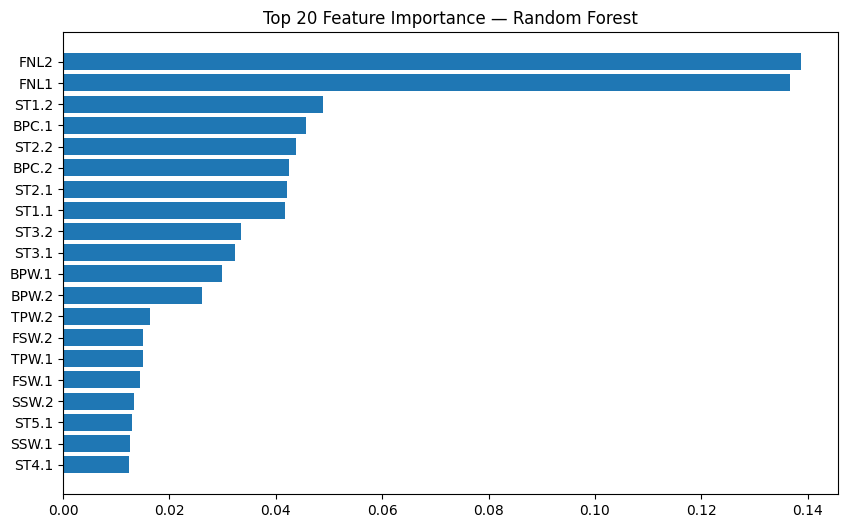

In [50]:
import matplotlib.pyplot as plt

top20 = feat_importance.head(20)

plt.figure(figsize=(10,6))
plt.barh(top20["feature"], top20["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importance — Random Forest")
plt.show()
